In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load dos dados via URL
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
print("Carregando o dataset...")
df = pd.read_csv(url)

Carregando o dataset...


In [2]:
# 2. Visualizar as primeiras linhas
print("Visualização das primeiras 5 linhas:")
display(df.head())

Visualização das primeiras 5 linhas:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# 3. Informações gerais do dataset (linhas, colunas, dados faltantes)
print(" ++++++ Informações da estrutura dos dados ++++++")
df.info()

 ++++++ Informações da estrutura dos dados ++++++
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20

In [4]:
# 4. Verificar o desbalanceamento das classes
print("\n++++++ Distribuição da Variável Alvo (Class) ++++++")
# 0 = Transação Normal | 1 = Transação Fraudulenta
contagem = df['Class'].value_counts()
print(contagem)

print("\n++++++ Distribuição da Variável Alvo (Class) em Porcentagem ++++++")
contagem_percentual = df['Class'].value_counts(normalize=True) * 100
print(contagem_percentual.round(2).astype(str) + '%')


++++++ Distribuição da Variável Alvo (Class) ++++++
Class
0    284315
1       492
Name: count, dtype: int64

++++++ Distribuição da Variável Alvo (Class) em Porcentagem ++++++
Class
0    99.83%
1     0.17%
Name: proportion, dtype: object


/tmp/ipykernel_77850/3856043793.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='Set2')


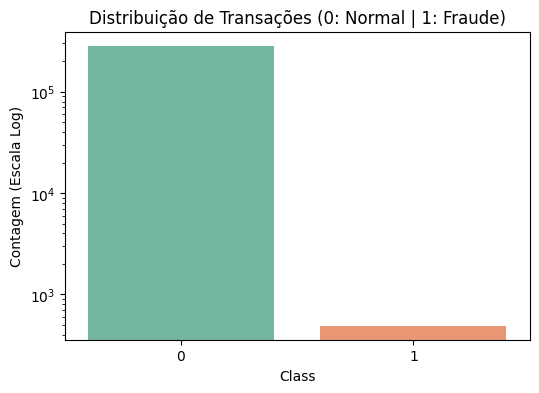

In [5]:
# 5. Criando um gráfico simples para visualizar o desbalanceamento
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df, palette='Set2')
plt.title('Distribuição de Transações (0: Normal | 1: Fraude)')
plt.yscale('log') # Usando escala logarítmica porque a diferença é brutal
plt.ylabel('Contagem (Escala Log)')
plt.show()

In [6]:
# Usar RobustScaler para lidar com outliers
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

# 1. Scaling das colunas Time e Amount
rob_scaler = RobustScaler()

df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))

# Removendo as colunas originais e organizando o DataFrame
df.drop(['Time','Amount'], axis=1, inplace=True)
df.insert(0, 'scaled_amount', df.pop('scaled_amount'))
df.insert(1, 'scaled_time', df.pop('scaled_time'))

print("++++++ Primeiras linhas com os dados escalonados ++++++")
display(df.head())

++++++ Primeiras linhas com os dados escalonados ++++++


,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,1.783274,-0.994983,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.269825,-0.994983,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,4.983721,-0.994972,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,1.418291,-0.994972,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,0.670579,-0.994960,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


In [7]:
# 2. Separar as features (X) da variável alvo (y)
X = df.drop('Class', axis=1)
y = df['Class']

# 3. Divisão de Treino e Teste)
# Usar stratify=y para garantir que a proporção minúscula de fraudes
# seja distribuída igualmente entre os dados de treino e teste.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\n--- Separação concluída com sucesso ---")
print(f"Dados de Treino: {len(X_train)} transações")
print(f"Dados de Teste: {len(X_test)} transações")


--- Separação concluída com sucesso ---
Dados de Treino: 227845 transações
Dados de Teste: 56962 transações


In [8]:
# Oversampling (SMOTE)
# Usar matemática para "inventar" novas transações fraudulentas sintéticas baseadas nas reais,
# equilibrando a balança sem perder dados legítimos.

from imblearn.over_sampling import SMOTE

print("Aplicando SMOTE aos dados de TREINO...")

# Inicializando o SMOTE
# sampling_strategy='minority' diz para igualar a classe minoritária à majoritária
smote = SMOTE(sampling_strategy='minority', random_state=42)

# Aplicando a transformação APENAS nas variáveis de treino
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\n++++++ Distribuição das Classes ANTES do SMOTE (Apenas Treino) ++++++")
print(y_train.value_counts())

print("\n++++++ Distribuição das Classes APÓS o SMOTE (Apenas Treino) ++++++")
contagem_smote = pd.Series(y_train_smote).value_counts()
print(contagem_smote)

print(f"\nSucesso! Agora temos {contagem_smote[0]} transações normais e {contagem_smote[1]} fraudes (reais + sintéticas) para treinar o algoritmo.")

Aplicando SMOTE aos dados de TREINO...

++++++ Distribuição das Classes ANTES do SMOTE (Apenas Treino) ++++++
Class
0    227451
1       394
Name: count, dtype: int64

++++++ Distribuição das Classes APÓS o SMOTE (Apenas Treino) ++++++
Class
0    227451
1    227451
Name: count, dtype: int64

Sucesso! Agora temos 227451 transações normais e 227451 fraudes (reais + sintéticas) para treinar o algoritmo.


In [9]:
# Undersampling
# Reduzir drasticamente as transações normais para que fiquem na mesma quantidade das fraudes (gera um modelo mais rápido, mas é jogado muita informação fora)

from imblearn.under_sampling import RandomUnderSampler

print("Aplicando Random Undersampling aos dados de TREINO...")

# Inicializando o Undersampler
rus = RandomUnderSampler(random_state=42)

# Aplicando a transformação APENAS nas variáveis de treino originais (X_train, y_train)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print("\n++++++ Distribuição das Classes APÓS o Undersampling (Apenas Treino) ++++++")
contagem_under = pd.Series(y_train_under).value_counts()
print(contagem_under)

print(f"\nFeito! Agora temos um dataset bem menor, com {contagem_under[0]} transações normais e {contagem_under[1]} fraudes.")

Aplicando Random Undersampling aos dados de TREINO...

++++++ Distribuição das Classes APÓS o Undersampling (Apenas Treino) ++++++
Class
0    394
1    394
Name: count, dtype: int64

Feito! Agora temos um dataset bem menor, com 394 transações normais e 394 fraudes.


⏳ Treinando modelo com dados SMOTE (Isso pode levar alguns minutos devido ao tamanho da base)...
⚡ Treinando modelo com dados Undersampling (Será quase instantâneo)...

Gerando previsões para avaliação...


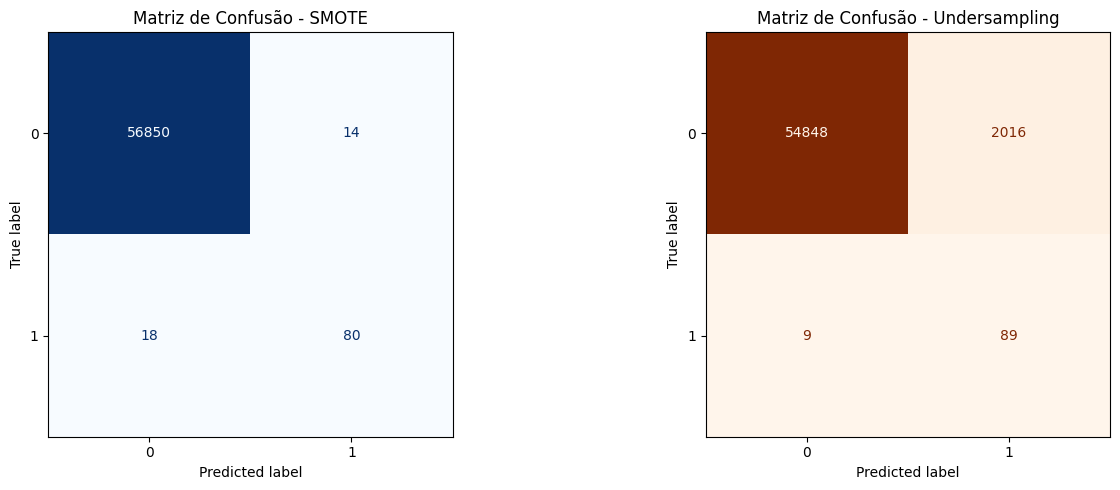


++++++ Relatório de Classificação: Modelo SMOTE ++++++
              precision    recall  f1-score   support

           0     0.9997    0.9998    0.9997     56864
           1     0.8511    0.8163    0.8333        98

    accuracy                         0.9994     56962
   macro avg     0.9254    0.9080    0.9165     56962
weighted avg     0.9994    0.9994    0.9994     56962


++++++ Relatório de Classificação: Modelo Undersampling ++++++
              precision    recall  f1-score   support

           0     0.9998    0.9645    0.9819     56864
           1     0.0423    0.9082    0.0808        98

    accuracy                         0.9644     56962
   macro avg     0.5211    0.9364    0.5313     56962
weighted avg     0.9982    0.9644    0.9803     56962



In [10]:
# Treinar dois modelos de Random Forest (Floresta Aleatória).
# Um aprenderá com a base gigantesca do SMOTE e o outro com a base reduzida do Undersampling.

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Instanciar os modelos
# n_jobs=-1 diz para o algoritmo usar todos os núcleos do processador para ir mais rápido
rf_smote = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_under = RandomForestClassifier(random_state=42, n_jobs=-1)

# 2. Treinar os modelos
print("⏳ Treinando modelo com dados SMOTE (Isso pode levar alguns minutos devido ao tamanho da base)...")
rf_smote.fit(X_train_smote, y_train_smote)

print("⚡ Treinando modelo com dados Undersampling (Será quase instantâneo)...")
rf_under.fit(X_train_under, y_train_under)

# 3. Fazendo as previsões nos dados de TESTE (X_test - o mundo real)
print("\nGerando previsões para avaliação...")
y_pred_smote = rf_smote.predict(X_test)
y_pred_under = rf_under.predict(X_test)

# 4. Avaliação Visual: Matrizes de Confusão
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_smote, ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusão - SMOTE')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_under, ax=axes[1], cmap='Oranges', colorbar=False)
axes[1].set_title('Matriz de Confusão - Undersampling')

plt.tight_layout()
plt.show()

# 5. Avaliação Numérica: Relatórios de Classificação
print("\n++++++ Relatório de Classificação: Modelo SMOTE ++++++")
print(classification_report(y_test, y_pred_smote, digits=4))

print("\n++++++ Relatório de Classificação: Modelo Undersampling ++++++")
print(classification_report(y_test, y_pred_under, digits=4))

Treinando o modelo XGBoost com os dados do SMOTE...
Costuma ser bem rápido, pois o algoritmo é altamente otimizado!



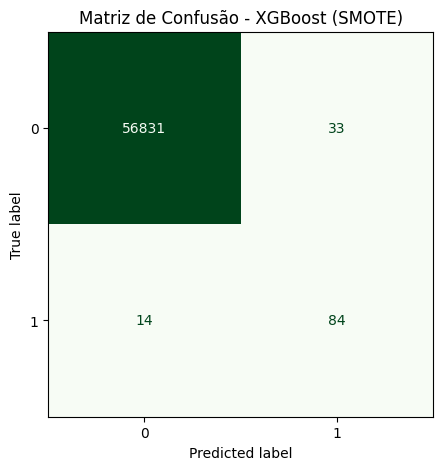


++++++ Relatório de Classificação: Modelo XGBoost ++++++
              precision    recall  f1-score   support

           0     0.9998    0.9994    0.9996     56864
           1     0.7179    0.8571    0.7814        98

    accuracy                         0.9992     56962
   macro avg     0.8589    0.9283    0.8905     56962
weighted avg     0.9993    0.9992    0.9992     56962



In [11]:
# Treinar usando XGBoost (Extreme Gradient Boosting)
# o XGBoost usa uma técnica chamada Boosting.
# Ele constrói uma árvore de cada vez, e cada nova árvore é focada exclusivamente
# em corrigir os erros que a árvore anterior cometeu

import xgboost as xgb
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Treinando o modelo XGBoost com os dados do SMOTE...")
print("Costuma ser bem rápido, pois o algoritmo é altamente otimizado!\n")

# 1. Instanciando o modelo
# eval_metric='logloss' é apenas para evitar warnings em versões mais recentes da biblioteca
xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')

# 2. Treinamento
xgb_model.fit(X_train_smote, y_train_smote)

# 3. Fazendo as previsões nos dados de TESTE (mundo real)
y_pred_xgb = xgb_model.predict(X_test)

# 4. Avaliação Visual: Matriz de Confusão
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, ax=ax, cmap='Greens', colorbar=False)
ax.set_title('Matriz de Confusão - XGBoost (SMOTE)')
plt.show()

# 5. Avaliação Numérica: Relatório de Classificação
print("\n++++++ Relatório de Classificação: Modelo XGBoost ++++++")
print(classification_report(y_test, y_pred_xgb, digits=4))

Configurando a Otimização de Hiperparâmetros (RandomizedSearchCV)...
Iniciando a busca pela melhor combinação...
Fitting 3 folds for each of 5 candidates, totalling 15 fits

++++++ Busca concluída! ++++++
Melhores Hiperparâmetros encontrados:
{'subsample': 1.0, 'n_estimators': 300, 'max_depth': 9, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


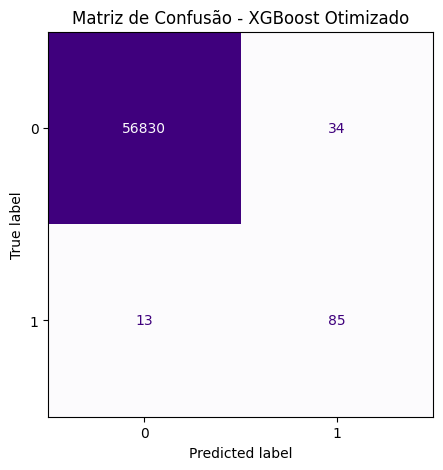


++++++ Relatório de Classificação: XGBoost Otimizado ++++++
              precision    recall  f1-score   support

           0     0.9998    0.9994    0.9996     56864
           1     0.7143    0.8673    0.7834        98

    accuracy                         0.9992     56962
   macro avg     0.8570    0.9334    0.8915     56962
weighted avg     0.9993    0.9992    0.9992     56962



In [12]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Configurando a Otimização de Hiperparâmetros (RandomizedSearchCV)...")

# 1. Definindo a "grade" de hiperparâmetros para testar
param_grid = {
    'n_estimators': [100, 200, 300],        # Número de árvores
    'max_depth': [3, 5, 7, 9],              # Profundidade máxima de cada árvore
    'learning_rate': [0.01, 0.05, 0.1, 0.2],# Taxa de aprendizado
    'subsample': [0.8, 1.0],                # % de amostras usadas por árvore (evita overfitting)
    'colsample_bytree': [0.8, 1.0]          # % de colunas usadas por árvore
}

# 2. Instanciando o modelo base
xgb_base = xgb.XGBClassifier(random_state=42, eval_metric='logloss')

# 3. Configurando a busca aleatória
# n_iter=5: testaremos 5 combinações aleatórias para economizar tempo no nosso laboratório.
# scoring='f1': Dizemos para o buscador focar na média harmônica entre Precision e Recall!
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=5,
    scoring='f1',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# 4. Iniciando o treinamento pesado (usando os dados do SMOTE)
print("Iniciando a busca pela melhor combinação...")
random_search.fit(X_train_smote, y_train_smote)

# 5. Resultados da busca
print("\n++++++ Busca concluída! ++++++")
print(f"Melhores Hiperparâmetros encontrados:\n{random_search.best_params_}")

# 6. Avaliando o MELHOR modelo encontrado nos dados de TESTE (Mundo Real)
best_xgb = random_search.best_estimator_
y_pred_best = best_xgb.predict(X_test)

# Avaliação Visual
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, ax=ax, cmap='Purples', colorbar=False)
ax.set_title('Matriz de Confusão - XGBoost Otimizado')
plt.show()

# Avaliação Numérica
print("\n++++++ Relatório de Classificação: XGBoost Otimizado ++++++")
print(classification_report(y_test, y_pred_best, digits=4))

Extraindo a inteligência do modelo XGBoost Otimizado...


/tmp/ipykernel_77850/3840887718.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importância', y='Variável', data=df_importancias.head(10), palette='viridis')


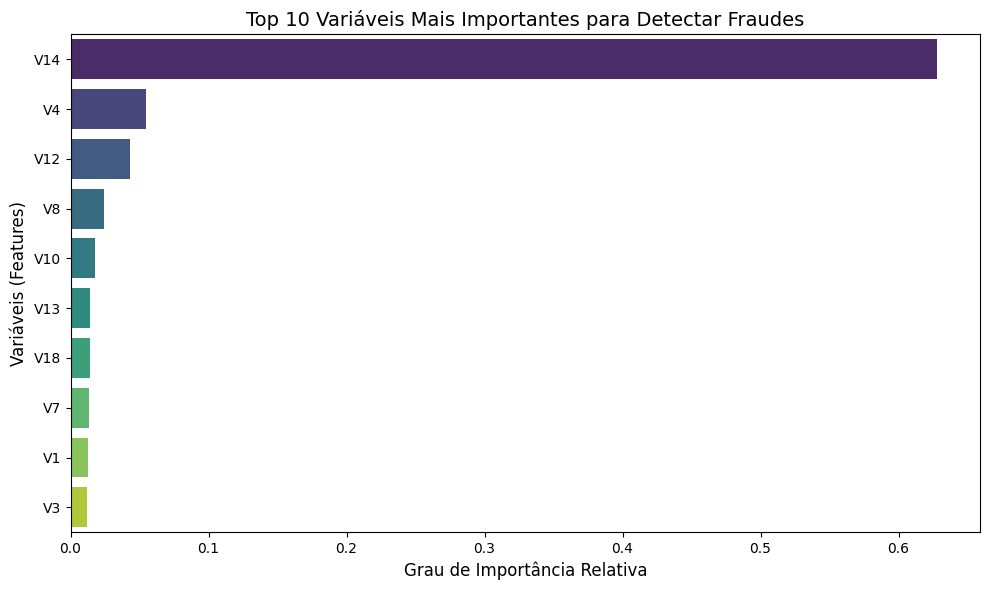


As 5 principais variáveis que estão guiando as decisões do modelo:


,Variável,Importância
15,V14,0.627627
5,V4,0.054893
13,V12,0.043002
9,V8,0.024062
11,V10,0.017538


In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("Extraindo a inteligência do modelo XGBoost Otimizado...")

# 1. Pegando os pesos (importâncias) calculados pelo XGBoost
importancias = best_xgb.feature_importances_

# 2. Criando um DataFrame para associar o nome da coluna com seu peso
df_importancias = pd.DataFrame({
    'Variável': X.columns,
    'Importância': importancias
}).sort_values(by='Importância', ascending=False)

# 3. Gerando o gráfico das 10 variáveis mais críticas
plt.figure(figsize=(10, 6))
sns.barplot(x='Importância', y='Variável', data=df_importancias.head(10), palette='viridis')
plt.title('Top 10 Variáveis Mais Importantes para Detectar Fraudes', fontsize=14)
plt.xlabel('Grau de Importância Relativa', fontsize=12)
plt.ylabel('Variáveis (Features)', fontsize=12)
plt.tight_layout()
plt.show()

print("\nAs 5 principais variáveis que estão guiando as decisões do modelo:")
display(df_importancias.head(5))